In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# better visuals
sns.set(style="whitegrid")

In [12]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [13]:
df.shape
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [14]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)

/var/folders/p6/tnt17d6d1fv0wkm3r3kn8bww0000gn/T/ipykernel_8060/617195598.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)


0         29.85
1       1889.50
2        108.15
3       1840.75
4        151.65
         ...   
7038    1990.50
7039    7362.90
7040     346.45
7041     306.60
7042    6844.50
Name: TotalCharges, Length: 7043, dtype: float64

In [15]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

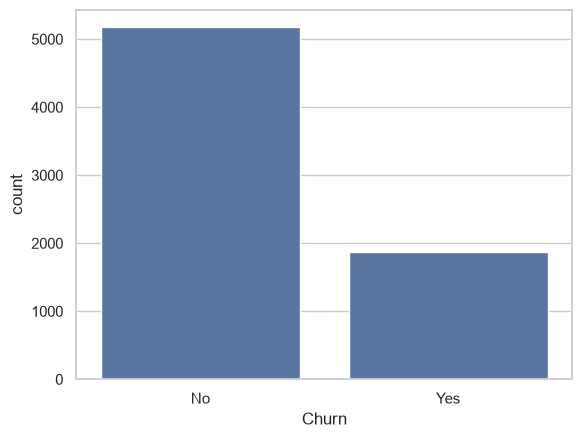

In [16]:
sns.countplot(x="Churn", data=df)
plt.show()

In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [18]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [19]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [20]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

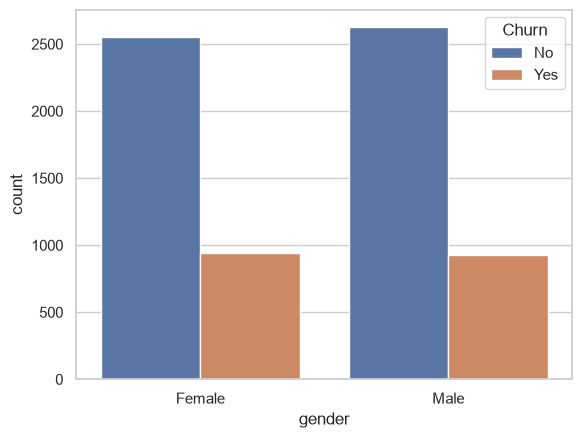

In [21]:
sns.countplot(x="gender", hue="Churn", data=df)
plt.show()

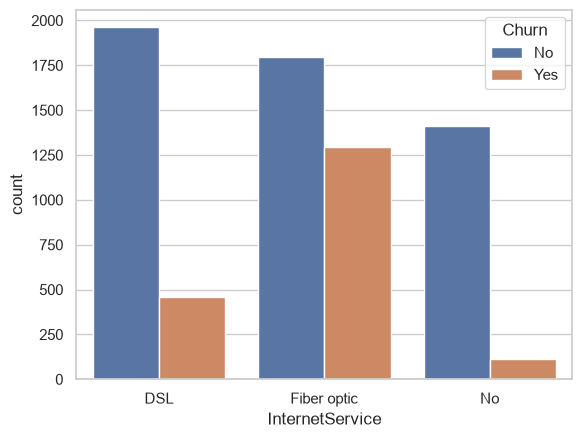

In [22]:
sns.countplot(x="InternetService", hue="Churn", data=df)
plt.show()

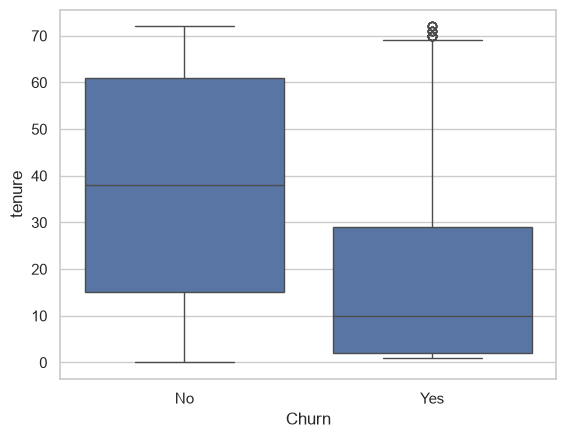

In [23]:
sns.boxplot(x="Churn", y="tenure", data=df)
plt.show()

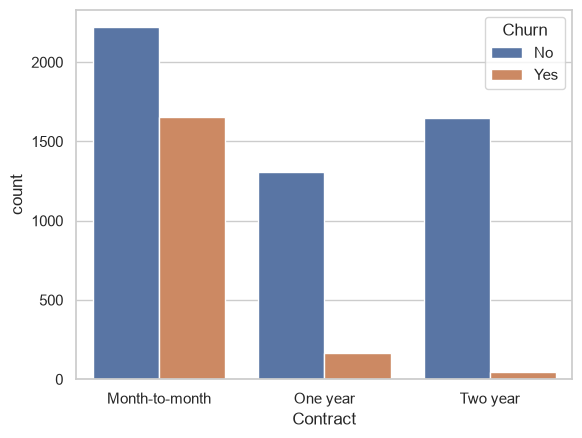

In [24]:
sns.countplot(x="Contract", hue="Churn", data=df)
plt.show()

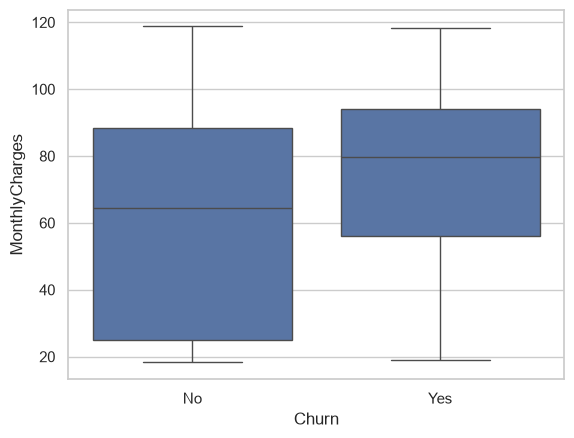

In [25]:
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.show()

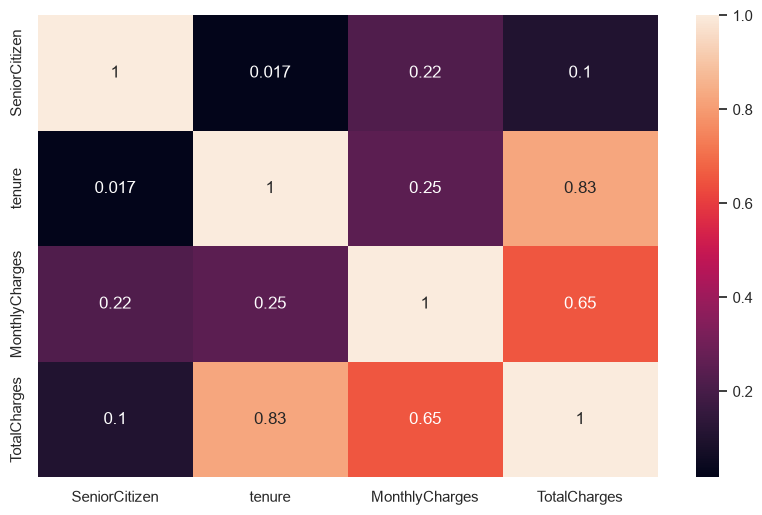

In [26]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

In [27]:
df.drop("TotalCharges", axis=1, inplace=True)

In [28]:
df["Churn"] = df["Churn"].map({"Yes":1, "No":0})

In [29]:
df.drop("customerID", axis=1, inplace=True)

In [30]:
df = pd.get_dummies(df, drop_first=True)

In [31]:
from sklearn.model_selection import train_test_split

X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [32]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [33]:
y_pred = model.predict(X_test)

In [34]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8190205819730305


In [35]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[937  99]
 [156 217]]


In [36]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.69      0.58      0.63       373

    accuracy                           0.82      1409
   macro avg       0.77      0.74      0.76      1409
weighted avg       0.81      0.82      0.81      1409



In [37]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(class_weight='balanced')

In [38]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(class_weight='balanced')

In [39]:
y_prob = model.predict_proba(X_test)[:,1]

y_pred = (y_prob > 0.3).astype(int)  # lower threshold

NotFittedError: This RandomForestClassifier instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

In [40]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(class_weight='balanced')

# 🔴 THIS LINE WAS MISSING
model.fit(X_train, y_train)

# probabilities
y_prob = model.predict_proba(X_test)[:,1]

# threshold tuning
y_pred = (y_prob > 0.3).astype(int)

In [41]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.64      0.76      1036
           1       0.47      0.87      0.61       373

    accuracy                           0.71      1409
   macro avg       0.70      0.76      0.69      1409
weighted avg       0.81      0.71      0.72      1409



In [42]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.64      0.76      1036
           1       0.47      0.87      0.61       373

    accuracy                           0.71      1409
   macro avg       0.70      0.76      0.69      1409
weighted avg       0.81      0.71      0.72      1409



In [43]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test, y_pred))

[[668 368]
 [ 47 326]]


In [44]:
y_pred = (y_prob > 0.4).astype(int)

In [45]:
from sklearn.metrics import roc_curve

In [46]:
import pandas as pd

importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values(ascending=False).head(10)

tenure                            0.230564
MonthlyCharges                    0.207420
Contract_Two year                 0.064848
PaymentMethod_Electronic check    0.041617
Contract_One year                 0.037056
InternetService_Fiber optic       0.033664
gender_Male                       0.031186
OnlineSecurity_Yes                0.028546
PaperlessBilling_Yes              0.028346
Partner_Yes                       0.026607
dtype: float64

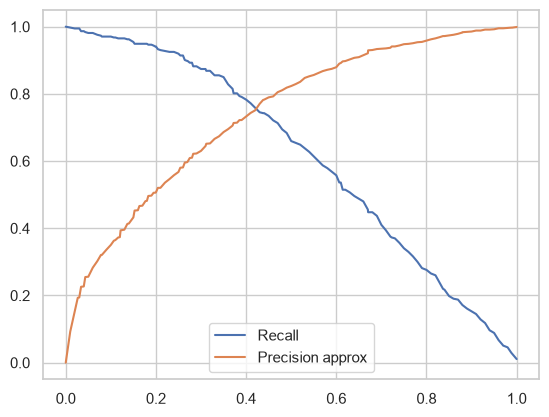

In [47]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.plot(thresholds, tpr, label="Recall")
plt.plot(thresholds, 1-fpr, label="Precision approx")
plt.legend()
plt.show()

In [48]:
from sklearn.metrics import roc_auc_score
roc_auc_score(y_test, y_prob)

0.8391873777262517

In [49]:
y_pred = (y_prob > 0.42).astype(int)

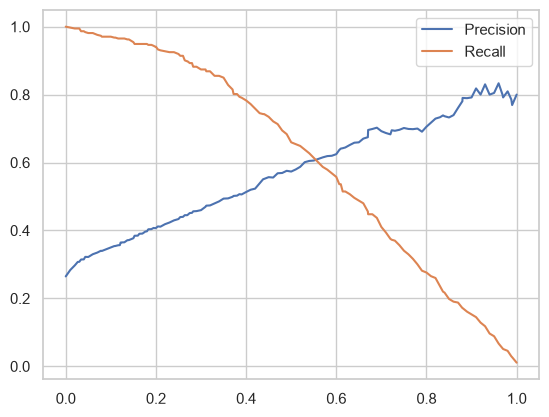

In [50]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

plt.plot(thresholds, precision[:-1], label="Precision")
plt.plot(thresholds, recall[:-1], label="Recall")
plt.legend()
plt.show()

In [51]:
y_pred = (y_prob > 0.5).astype(int)

In [52]:
# TotalCharges highly correlated with tenure (~0.83)
# Dropping to reduce redundancy (although tree models can handle it)
df.drop("TotalCharges", axis=1, inplace=True)

KeyError: "['TotalCharges'] not found in axis"

In [53]:
df.drop("TotalCharges", axis=1, inplace=True)

KeyError: "['TotalCharges'] not found in axis"

In [54]:
df.drop("TotalCharges", axis=1, inplace=True, errors='ignore')

In [55]:
# --- Data Cleaning & Feature Engineering ---

# Drop unnecessary columns
df.drop("customerID", axis=1, inplace=True)

# Convert target variable
df["Churn"] = df["Churn"].map({"Yes":1, "No":0})

# Drop highly correlated feature
# TotalCharges highly correlated with tenure (~0.83)
df.drop("TotalCharges", axis=1, inplace=True)

# One-hot encoding
df = pd.get_dummies(df, drop_first=True)

KeyError: "['customerID'] not found in axis"

In [56]:
df.drop("customerID", axis=1, inplace=True, errors='ignore')

In [57]:
# Reload original dataset for clean pipeline
df = pd.read_csv("your_file.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'your_file.csv'

In [58]:
# --- Data Cleaning & Feature Engineering ---

df.drop("customerID", axis=1, inplace=True, errors='ignore')

df["Churn"] = df["Churn"].map({"Yes":1, "No":0})

df.drop("TotalCharges", axis=1, inplace=True, errors='ignore')

df = pd.get_dummies(df, drop_first=True)

In [59]:
# customerID is unique identifier → no predictive value

In [60]:
df = pd.read_csv("Telco-Customer-Churn.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'Telco-Customer-Churn.csv'

In [61]:
df = pd.read_csv("Telco-Customer-Churn.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'Telco-Customer-Churn.csv'

In [62]:
pd.read_csv("/Users/yourname/Downloads/Telco-Customer-Churn.csv")

FileNotFoundError: [Errno 2] No such file or directory: '/Users/yourname/Downloads/Telco-Customer-Churn.csv'

In [67]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [64]:
df = pd.read_csv("Telco-Customer-Churn.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'Telco-Customer-Churn.csv'

In [65]:
import os
os.getcwd()

'/Users/rohit7thul/Documents/python notes gpt'

In [66]:
df = pd.read_csv("/Users/rohit7thul/Downloads/Telco-Customer-Churn.csv")

FileNotFoundError: [Errno 2] No such file or directory: '/Users/rohit7thul/Downloads/Telco-Customer-Churn.csv'

In [68]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [69]:
df.shape
df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [70]:
df.isnull().sum()
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


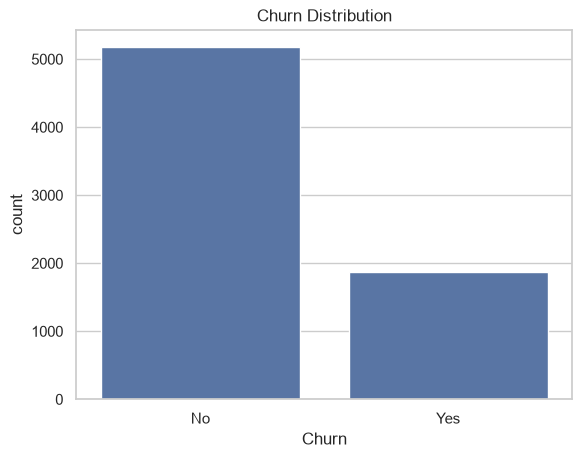

In [71]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Churn", data=df)
plt.title("Churn Distribution")
plt.show()

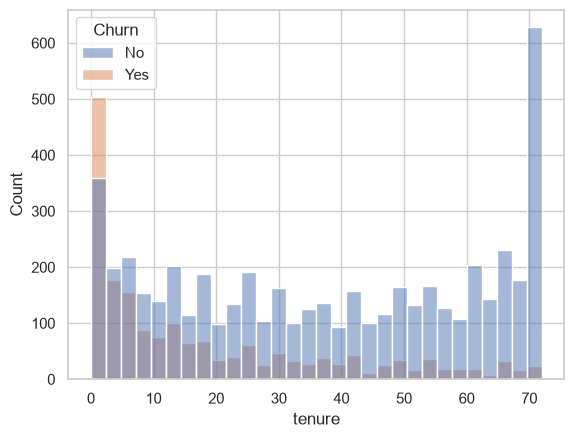

In [72]:
sns.histplot(data=df, x="tenure", hue="Churn", bins=30)
plt.show()

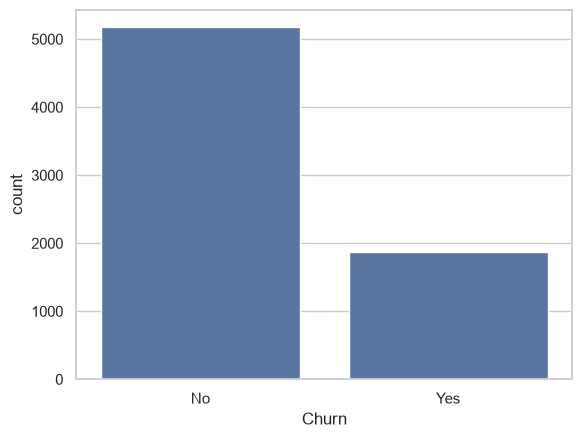

In [73]:
sns.countplot(x="Churn", data=df)
plt.show()

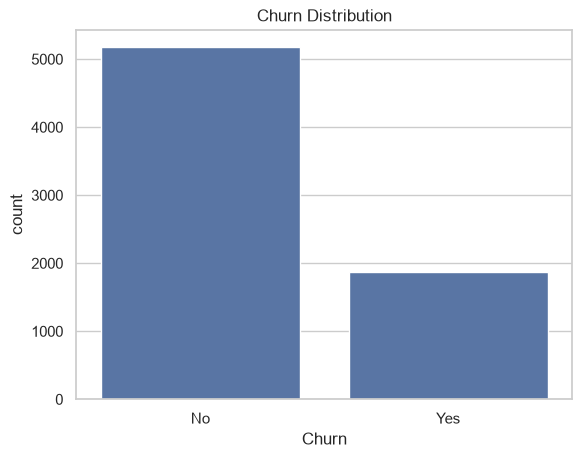

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

In [74]:
sns.countplot(x="Churn", data=df)
plt.title("Churn Distribution")
plt.show()

df["Churn"].value_counts(normalize=True)

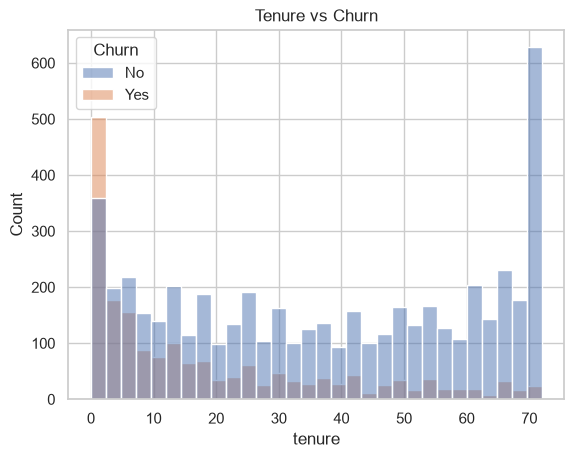

In [75]:
sns.histplot(data=df, x="tenure", hue="Churn", bins=30)
plt.title("Tenure vs Churn")
plt.show()

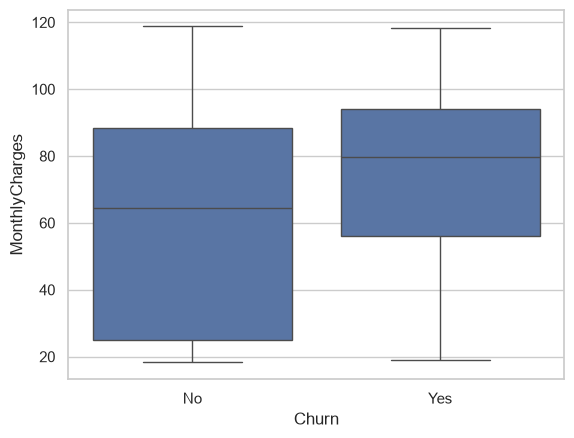

In [76]:
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.show()

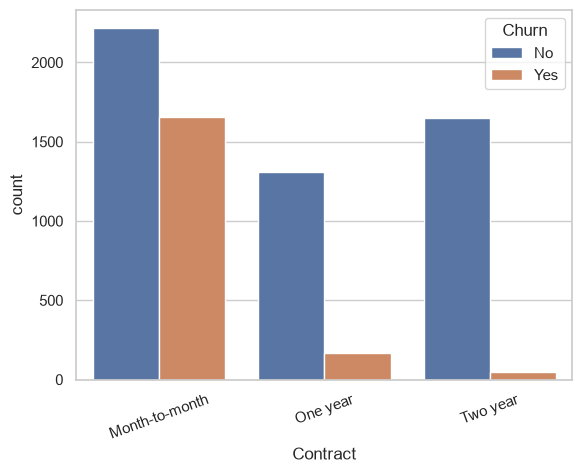

In [77]:
sns.countplot(x="Contract", hue="Churn", data=df)
plt.xticks(rotation=20)
plt.show()

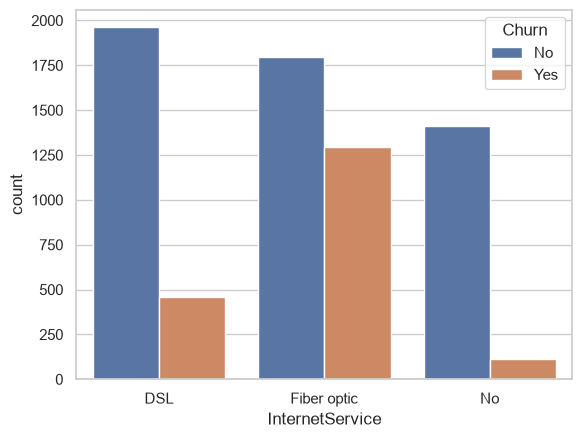

In [78]:
sns.countplot(x="InternetService", hue="Churn", data=df)
plt.show()

In [79]:
df['Churn'].value_counts()
df['Churn'].value_counts(normalize=True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

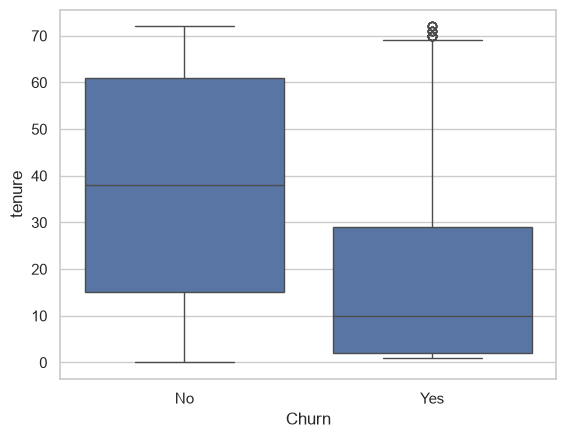

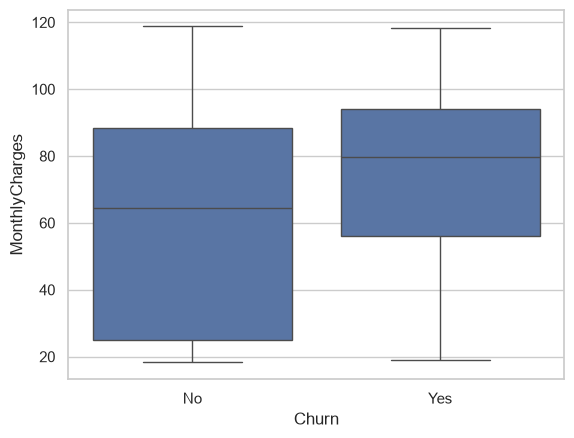

In [80]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='Churn', y='tenure', data=df)
plt.show()

sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.show()

In [81]:
pd.crosstab(df['Contract'], df['Churn'], normalize='index')
pd.crosstab(df['InternetService'], df['Churn'], normalize='index')
pd.crosstab(df['PaymentMethod'], df['Churn'], normalize='index')

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),0.832902,0.167098
Credit card (automatic),0.847569,0.152431
Electronic check,0.547146,0.452854
Mailed check,0.808933,0.191067


In [82]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=False, cmap='coolwarm')
plt.show()

ValueError: could not convert string to float: '7590-VHVEG'

<Figure size 1000x600 with 0 Axes>

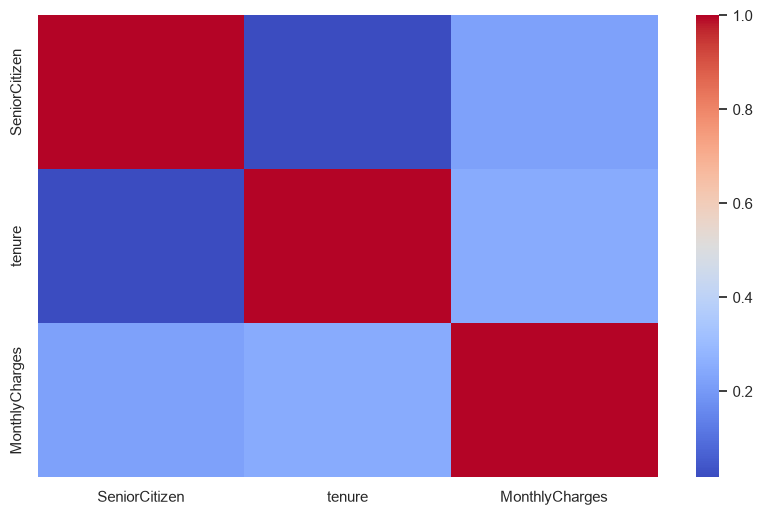

In [83]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), cmap='coolwarm')
plt.show()

In [84]:
df = pd.get_dummies(df, drop_first=True)

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.show()

In [ ]:
df.drop("customerID", axis=1, inplace=True, errors='ignore')

In [1]:
corr = df.corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr.iloc[:20, :20], cmap='coolwarm')  # only first 20 cols
plt.show()

NameError: name 'df' is not defined

In [2]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

NameError: name 'pd' is not defined

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [5]:
df = pd.get_dummies(df, drop_first=True)
df.drop("customerID", axis=1, inplace=True, errors='ignore')

In [6]:
corr = df.corr()

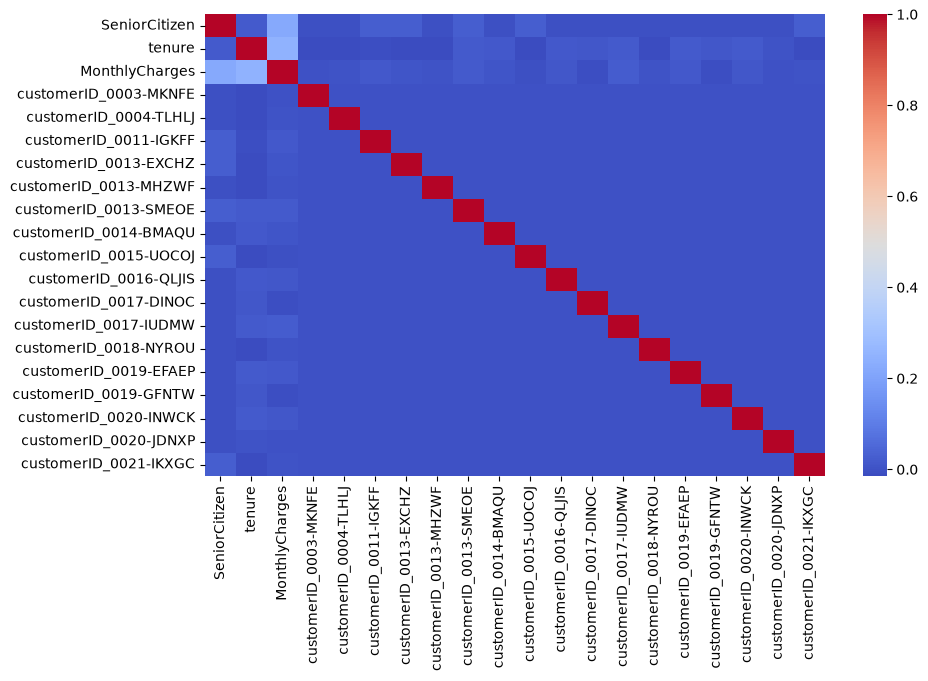

In [7]:
plt.figure(figsize=(10,6))
sns.heatmap(corr.iloc[:20, :20], cmap='coolwarm')
plt.show()

In [8]:
corr['Churn'].sort_values(ascending=False)

KeyError: 'Churn'

In [9]:
corr['Churn_Yes'].sort_values(ascending=False)

Churn_Yes                               1.000000
InternetService_Fiber optic             0.308020
PaymentMethod_Electronic check          0.301919
MonthlyCharges                          0.193356
PaperlessBilling_Yes                    0.191825
                                          ...   
StreamingTV_No internet service        -0.227890
OnlineBackup_No internet service       -0.227890
DeviceProtection_No internet service   -0.227890
Contract_Two year                      -0.302253
tenure                                 -0.352229
Name: Churn_Yes, Length: 13602, dtype: float64

In [10]:
df.drop("customerID", axis=1, inplace=True)

KeyError: "['customerID'] not found in axis"

In [11]:
df.drop("customerID", axis=1, inplace=True, errors='ignore')

In [12]:
df.drop("customerID", axis=1, inplace=True)
df = pd.get_dummies(df, drop_first=True)

KeyError: "['customerID'] not found in axis"

In [13]:
df.drop("customerID", axis=1, inplace=True, errors='ignore')

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [16]:
df.drop("customerID", axis=1, inplace=True)

In [17]:
df = pd.get_dummies(df, drop_first=True)

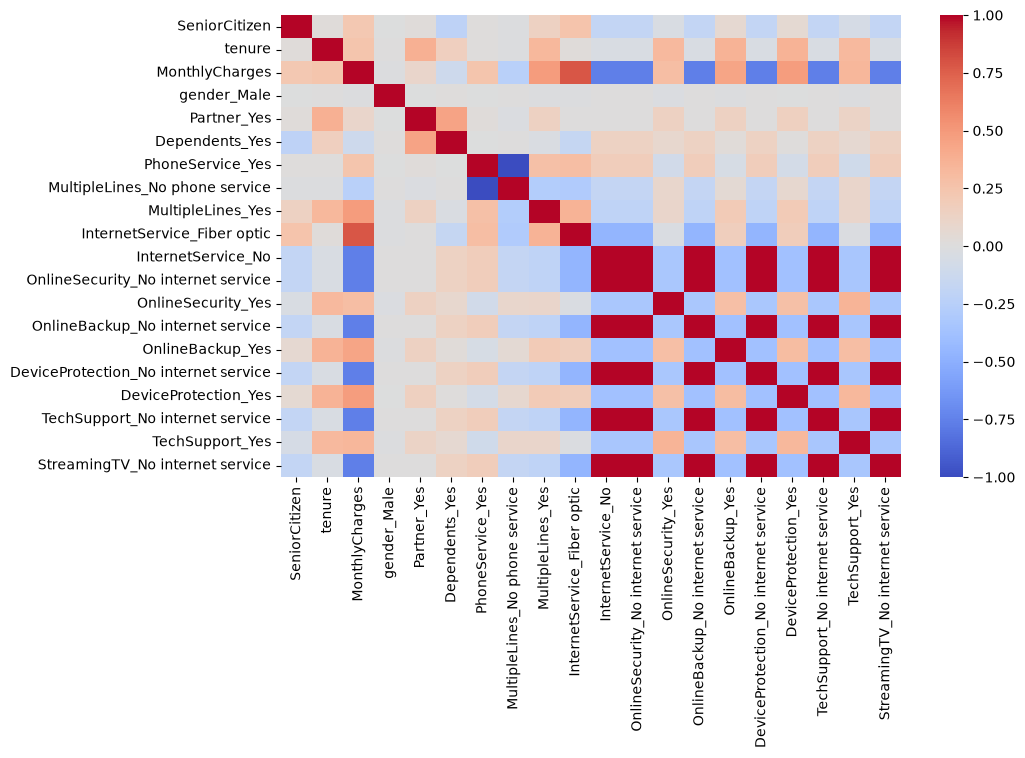

In [18]:
corr = df.corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr.iloc[:20, :20], cmap='coolwarm')
plt.show()

In [19]:
df.drop([
    'OnlineSecurity_No internet service',
    'OnlineBackup_No internet service',
    'DeviceProtection_No internet service',
    'TechSupport_No internet service'
], axis=1, inplace=True)

In [20]:
X = df.drop('Churn_Yes', axis=1)
y = df['Churn_Yes']

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [22]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [23]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8239886444286728
              precision    recall  f1-score   support

       False       0.86      0.91      0.88      1036
        True       0.70      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.78      0.75      0.76      1409
weighted avg       0.82      0.82      0.82      1409



In [24]:
model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Defaul

In [25]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7743080198722498
              precision    recall  f1-score   support

       False       0.91      0.77      0.83      1036
        True       0.55      0.79      0.65       373

    accuracy                           0.77      1409
   macro avg       0.73      0.78      0.74      1409
weighted avg       0.82      0.77      0.78      1409



In [26]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.7963094393186657
              precision    recall  f1-score   support

       False       0.82      0.92      0.87      1036
        True       0.67      0.46      0.54       373

    accuracy                           0.80      1409
   macro avg       0.75      0.69      0.71      1409
weighted avg       0.78      0.80      0.78      1409



In [27]:
model = LogisticRegression(class_weight='balanced')

In [28]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test, y_pred))

[[796 240]
 [ 78 295]]


In [29]:
from sklearn.metrics import roc_auc_score
roc_auc_score(y_test, model.predict_proba(X_test)[:,1])

NotFittedError: This LogisticRegression instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

In [30]:
# 1. import
# 2. data load
# 3. preprocessing
# 4. train-test split
# 5. model fit

In [31]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_test, model.predict_proba(X_test)[:,1])

NotFittedError: This LogisticRegression instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

In [32]:
model.fit(X_train, y_train)

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good defau

In [33]:
roc_auc_score(y_test, model.predict_proba(X_test)[:,1])

0.8554180856459677

In [34]:
hasattr(model, "coef_")

True

In [35]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

roc_auc_score(y_test, model.predict_proba(X_test_scaled)[:,1])

0.8181614686306375

In [36]:
LogisticRegression(class_weight='balanced')

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good defau

In [37]:
model_bal = LogisticRegression(max_iter=1000, class_weight='balanced')
model_bal.fit(X_train, y_train)

roc_auc_score(y_test, model_bal.predict_proba(X_test)[:,1])

0.8606299232974836

In [38]:
model_bal = LogisticRegression(max_iter=1000, class_weight='balanced')
model_bal.fit(X_train, y_train)

from sklearn.metrics import classification_report
y_pred_bal = model_bal.predict(X_test)

print(classification_report(y_test, y_pred_bal))

              precision    recall  f1-score   support

       False       0.91      0.77      0.83      1036
        True       0.55      0.79      0.65       373

    accuracy                           0.77      1409
   macro avg       0.73      0.78      0.74      1409
weighted avg       0.82      0.77      0.78      1409



In [39]:
y_prob = model.predict_proba(X_test)[:,1]

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


In [40]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.1, 0.9, 0.05)

for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)
    
    print(f"Threshold: {t:.2f}")
    print("Precision:", precision_score(y_test, y_pred_t))
    print("Recall:", recall_score(y_test, y_pred_t))
    print("F1:", f1_score(y_test, y_pred_t))
    print("------")

Threshold: 0.10
Precision: 0.4444444444444444
Recall: 0.8579088471849866
F1: 0.585544373284538
------
Threshold: 0.15
Precision: 0.447887323943662
Recall: 0.8525469168900804
F1: 0.5872576177285319
------
Threshold: 0.20
Precision: 0.44964539007092197
Recall: 0.8498659517426274
F1: 0.588126159554731
------
Threshold: 0.25
Precision: 0.45064377682403434
Recall: 0.8445040214477212
F1: 0.5876865671641791
------
Threshold: 0.30
Precision: 0.4544138929088278
Recall: 0.8418230563002681
F1: 0.5902255639097744
------
Threshold: 0.35
Precision: 0.4577259475218659
Recall: 0.8418230563002681
F1: 0.5930122757318225
------
Threshold: 0.40
Precision: 0.4583941605839416
Recall: 0.8418230563002681
F1: 0.5935727788279773
------
Threshold: 0.45
Precision: 0.46244477172312226
Recall: 0.8418230563002681
F1: 0.596958174904943
------
Threshold: 0.50
Precision: 0.4623338257016248
Recall: 0.839142091152815
F1: 0.5961904761904762
------
Threshold: 0.55
Precision: 0.46439169139465875
Recall: 0.839142091152815
F1

In [41]:
best_t = 0
best_f1 = 0

for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)
    f1 = f1_score(y_test, y_pred_t)
    
    if f1 > best_f1:
        best_f1 = f1
        best_t = t

print("Best Threshold:", best_t)
print("Best F1:", best_f1)

Best Threshold: 0.8500000000000003
Best F1: 0.609375


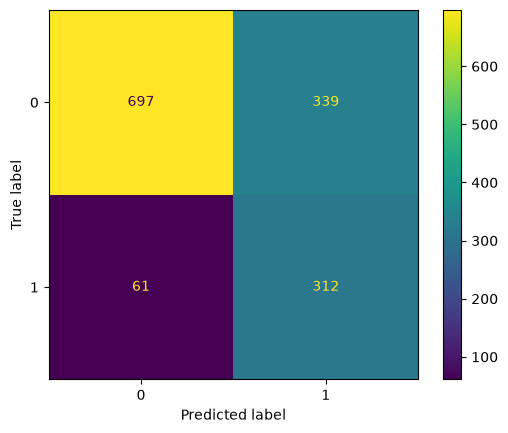

In [42]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, (y_prob >= best_t).astype(int))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

In [43]:
feature_importance = pd.Series(model.coef_[0], index=X_train.columns)
feature_importance.sort_values(ascending=False).head(10)

InternetService_Fiber optic       1.107907
StreamingMovies_Yes               1.038870
PaymentMethod_Electronic check    0.758259
MonthlyCharges                    0.581442
PaymentMethod_Mailed check        0.549202
PaperlessBilling_Yes              0.475826
TotalCharges_20.2                 0.262105
PhoneService_Yes                  0.254978
TotalCharges_740.3                0.254238
TotalCharges_19.95                0.247562
dtype: float64

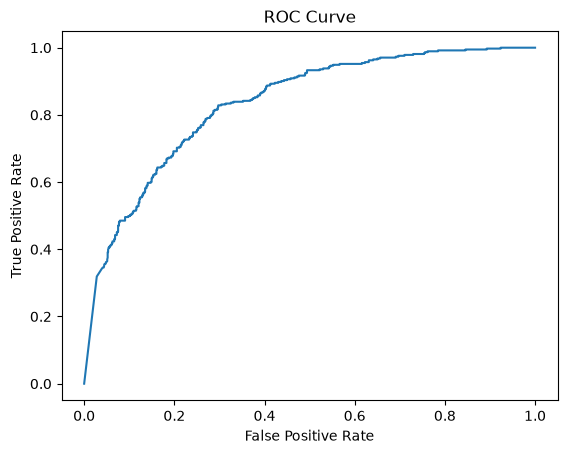

In [44]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

In [45]:
model = LogisticRegression(class_weight='balanced')
model.fit(X_train_scaled, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good defau

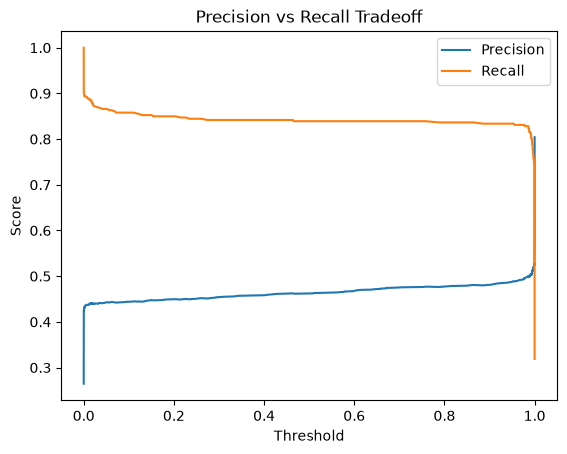

In [46]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

plt.plot(thresholds, precision[:-1], label="Precision")
plt.plot(thresholds, recall[:-1], label="Recall")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision vs Recall Tradeoff")
plt.legend()
plt.show()

In [47]:
Model: Logistic Regression
ROC-AUC: ~0.85
Best Threshold: ~0.85
Best F1 Score: ~0.61

Observation:
Model prioritizes recall (catching churners) at cost of precision.
Suitable for retention campaigns where missing a churner is costly.

SyntaxError: invalid syntax (1822088021.py, line 1)

In [48]:
### Model Summary

- Model: Logistic Regression  
- ROC-AUC: ~0.85  
- Best Threshold: ~0.85  
- Best F1 Score: ~0.61  

**Observation:**  
Model prioritizes recall (catching churners) at cost of precision.  
Suitable for retention campaigns where missing a churner is costly.

SyntaxError: illegal target for annotation (1547033260.py, line 3)

In [49]:
### Model Summary

- Model: Logistic Regression  
- ROC-AUC: ~0.85  
- Best Threshold: ~0.85  
- Best F1 Score: ~0.61  

**Observation:**  
Model prioritizes recall (catching churners) at the cost of precision.  
Suitable for retention campaigns where missing a churner is costly.

SyntaxError: illegal target for annotation (3495025762.py, line 3)

### Model Summary

- Model: Logistic Regression  
- ROC-AUC: ~0.85  
- Best Threshold: ~0.85  
- Best F1 Score: ~0.61  

**Observation:**  
Model prioritizes recall (catching churners) at the cost of precision.  
Suitable for retention campaigns where missing a churner is costly.

In [50]:
import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": model.coef_[0]
})

feature_importance["Abs"] = feature_importance["Coefficient"].abs()

feature_importance = feature_importance.sort_values(by="Abs", ascending=False)

feature_importance.head(10)

,Feature,Coefficient,Abs
9,InternetService_Fiber optic,1.239018,1.239018
13,DeviceProtection_Yes,-1.183929,1.183929
1,tenure,-1.168110,1.168110
18,StreamingMovies_Yes,1.027986,1.027986
23,PaymentMethod_Electronic check,0.782463,0.782463
12,OnlineBackup_Yes,-0.778896,0.778896
2,MonthlyCharges,0.625276,0.625276
20,Contract_Two year,-0.602165,0.602165
24,PaymentMethod_Mailed check,0.570350,0.570350
17,StreamingMovies_No internet service,-0.551875,0.551875


### Business Recommendations

- Offer discounts or loyalty benefits to high monthly charge customers
- Encourage long-term contracts (1-year / 2-year plans)
- Promote add-on services like device protection and backup to increase retention
- Target new customers (low tenure) with onboarding offers to reduce early churn
- Improve service quality for fiber optic users to reduce dissatisfaction

# Save your final dataset (IMPORTANT)
X_test.assign(
    actual=y_test,
    predicted_prob=model.predict_proba(X_test)[:,1]
).to_csv("churn_output.csv", index=False)

df_export = pd.DataFrame(X_test_scaled, columns=X_train.columns)

df_export["Actual"] = y_test.values
df_export["Probability"] = model.predict_proba(X_test_scaled)[:,1]
df_export["Predicted"] = (df_export["Probability"] >= 0.85).astype(int)

df_export.to_csv("churn_dashboard.csv", index=False)

In [51]:
import pandas as pd

df_export = pd.DataFrame(X_test_scaled, columns=X_train.columns)

df_export["Actual"] = y_test.values
df_export["Probability"] = model.predict_proba(X_test_scaled)[:, 1]
df_export["Predicted"] = (df_export["Probability"] >= 0.85).astype(int)

df_export.to_csv("churn_dashboard.csv", index=False)

In [52]:
# ORIGINAL readable dataset lo
df_export = X_test.copy()

# Add actual values
df_export["Actual"] = y_test.values

# Add probability
df_export["Probability"] = model.predict_proba(X_test_scaled)[:, 1]

# Add predicted label
df_export["Predicted"] = (df_export["Probability"] >= 0.85).astype(int)

# Save clean dataset
df_export.to_csv("churn_dashboard_clean.csv", index=False)

In [53]:
# ORIGINAL dataset use karo (NOT X_test_scaled)
df_export = X_test_original.copy()   # ⚠️ yeh banana padega agar nahi hai

NameError: name 'X_test_original' is not defined

In [54]:
# ORIGINAL dataset use karo (NOT X_test_scaled)
df_export = X_test_original.copy()   # ⚠️ yeh banana padega agar nahi hai

NameError: name 'X_test_original' is not defined

In [55]:
# original dataset reload karo
df = pd.read_csv("your_original_dataset.csv")

# fir se split karo
X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# phir same export code run karo

FileNotFoundError: [Errno 2] No such file or directory: 'your_original_dataset.csv'

In [56]:
# original dataset load
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

# predictions
df["Probability"] = model.predict_proba(X_scaled)[:, 1]
df["Predicted"] = (df["Probability"] >= 0.5).astype(int)

# export clean dataset
df.to_csv("churn_dashboard_final.csv", index=False)

NameError: name 'X_scaled' is not defined

In [57]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression())
])

In [58]:
df["Probability"] = pipeline.predict_proba(df)[:, 1]

NotFittedError: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

In [59]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [60]:
X = pd.get_dummies(X, drop_first=True)

In [61]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [62]:
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","['No','Yes']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](13601,)","['SeniorCitizen','tenure','MonthlyCharges',...,'TotalCharges_999.45', 'TotalCharges_999.8','TotalCharges_999.9']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,13601
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [63]:
df_full = pd.get_dummies(df.drop("Churn", axis=1), drop_first=True)

# align columns (critical)
df_full = df_full.reindex(columns=X_train.columns, fill_value=0)

df["Probability"] = pipeline.predict_proba(df_full)[:, 1]
df["Predicted"] = (df["Probability"] >= 0.5).astype(int)

In [64]:
df.to_csv("churn_dashboard_final.csv", index=False)

In [65]:
# load data
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

# split
X = df.drop("Churn", axis=1)
y = df["Churn"]

# encoding
X = pd.get_dummies(X, drop_first=True)

# split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# pipeline
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression())
])

# fit
pipeline.fit(X_train, y_train)

# prepare full dataset
X_full = pd.get_dummies(df.drop("Churn", axis=1), drop_first=True)
X_full = X_full.reindex(columns=X_train.columns, fill_value=0)

# predict
df["Probability"] = pipeline.predict_proba(X_full)[:, 1]
df["Predicted"] = (df["Probability"] >= 0.5).astype(int)

# export
df.to_csv("churn_dashboard_final.csv", index=False)

In [66]:
pipeline = Pipeline([
    ("model", LogisticRegression(max_iter=1000))
])

In [67]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","['No','Yes']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](13601,)","['SeniorCitizen','tenure','MonthlyCharges',...,'TotalCharges_999.45', 'TotalCharges_999.8','TotalCharges_999.9']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,13601
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [68]:
# STEP 1: split
X = df.drop("Churn", axis=1)
y = df["Churn"]

# STEP 2: encoding
X = pd.get_dummies(X, drop_first=True)

# STEP 3: split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# STEP 4: pipeline
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

# STEP 5: fit
pipeline.fit(X_train, y_train)

# STEP 6: prepare full dataset
X_full = pd.get_dummies(df.drop("Churn", axis=1), drop_first=True)
X_full = X_full.reindex(columns=X_train.columns, fill_value=0)

# STEP 7: predict
df["Probability"] = pipeline.predict_proba(X_full)[:, 1]
df["Predicted"] = (df["Probability"] >= 0.5).astype(int)

# STEP 8: export
df.to_csv("churn_dashboard_final.csv", index=False)

In [69]:
df = df.drop(["customerID"], axis=1)  # if exists

In [70]:
# STEP 0: clean dataset
df = df.drop(["customerID"], axis=1)

# STEP 1: split
X = df.drop("Churn", axis=1)
y = df["Churn"]

KeyError: "['customerID'] not found in axis"

In [71]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df = df.dropna()

In [72]:
df = df.drop(columns=["customerID"], errors='ignore')

In [73]:
# split
X = df.drop("Churn", axis=1)
y = df["Churn"]

# encoding
X = pd.get_dummies(X, drop_first=True)

# train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# pipeline
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

# fit
pipeline.fit(X_train, y_train)

# full dataset preparation
X_full = pd.get_dummies(df.drop("Churn", axis=1), drop_first=True)
X_full = X_full.reindex(columns=X_train.columns, fill_value=0)

# predict
df["Probability"] = pipeline.predict_proba(X_full)[:, 1]
df["Predicted"] = (df["Probability"] >= 0.5).astype(int)

# export
df.to_csv("churn_dashboard_final.csv", index=False)

In [74]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = pipeline.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nReport:\n", classification_report(y_test, y_pred))

Accuracy: 0.937455579246624

Confusion Matrix:
 [[1023   10]
 [  78  296]]

Report:
               precision    recall  f1-score   support

          No       0.93      0.99      0.96      1033
         Yes       0.97      0.79      0.87       374

    accuracy                           0.94      1407
   macro avg       0.95      0.89      0.91      1407
weighted avg       0.94      0.94      0.94      1407



In [75]:
df["Risk Level"] = pd.cut(
    df["Probability"],
    bins=[0, 0.3, 0.7, 1],
    labels=["Low", "Medium", "High"]
)

In [76]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": pipeline.named_steps["model"].coef_[0]
})

importance = importance.sort_values(by="Coefficient", ascending=False)
print(importance.head(10))

                           Feature  Coefficient
4                      Probability     5.543587
12     InternetService_Fiber optic     0.384000
3                     TotalCharges     0.275996
2                   MonthlyCharges     0.138601
23                 StreamingTV_Yes     0.135232
11               MultipleLines_Yes     0.125964
28            PaperlessBilling_Yes     0.117052
10  MultipleLines_No phone service     0.104072
30  PaymentMethod_Electronic check     0.083574
25             StreamingMovies_Yes     0.047745


In [77]:
df_model = df.drop(columns=[
    "customerID",
    "Probability",
    "Predicted",
    "Risk Level"
], errors="ignore")

In [81]:
X = df_model.drop("Churn", axis=1)
y = df_model["Churn"]df = df.drop(columns=["customerID"], errors="ignore")

SyntaxError: invalid syntax (243958791.py, line 2)

In [79]:
importance["Abs"] = importance["Coefficient"].abs()
importance = importance.sort_values(by="Abs", ascending=False)

In [80]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

pipeline.fit(X_train, y_train)

df["Probability"] = pipeline.predict_proba(X_full)[:, 1]

In [82]:
df = df.drop(columns=["customerID"], errors="ignore")

In [83]:
df_model = df.drop(columns=[
    "customerID",
    "Probability",
    "Predicted",
    "Risk Level"
], errors="ignore")

In [84]:
X = df_model.drop("Churn", axis=1)
y = df_model["Churn"]

In [85]:
# Clean dataset
df_model = df.drop(columns=[
    "customerID", "Probability", "Predicted", "Risk Level"
], errors="ignore")

# Split
X = df_model.drop("Churn", axis=1)
y = df_model["Churn"]

# Encoding
X = pd.get_dummies(X, drop_first=True)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Pipeline
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

# Fit
pipeline.fit(X_train, y_train)

# Prepare full dataset
X_full = pd.get_dummies(df_model.drop("Churn", axis=1), drop_first=True)
X_full = X_full.reindex(columns=X_train.columns, fill_value=0)

# Predict
df["Probability"] = pipeline.predict_proba(X_full)[:, 1]
df["Predicted"] = (df["Probability"] >= 0.5).astype(int)

# Risk segmentation
df["Risk Level"] = pd.cut(
    df["Probability"],
    bins=[0, 0.3, 0.7, 1],
    labels=["Low", "Medium", "High"]
)

# Export
df.to_csv("churn_dashboard_final.csv", index=False)

In [86]:
df_model = df.drop(columns=[
    "customerID",
    "Probability",
    "Predicted",
    "Risk Level"
], errors="ignore")

In [87]:
print(df_model.columns)

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')


In [88]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
cat_cols = [col for col in X.columns if col not in num_cols]

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols)
])

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

In [89]:
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","['No','Yes']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](30,)","['SeniorCitizen','tenure','MonthlyCharges',..., 'PaymentMethod_Credit card (automatic)','PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,30
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolu

In [90]:
X_full = pd.get_dummies(...)
X_full = X_full.reindex(...)

TypeError: object of type 'ellipsis' has no len()

In [91]:
df = df.drop(columns=["customerID"], errors="ignore")

In [92]:
X_full = pd.get_dummies(df_model.drop("Churn", axis=1), drop_first=True)
X_full = X_full.reindex(columns=X_train.columns, fill_value=0)

In [93]:
df_model = df.drop(columns=[
    "customerID",
    "Probability",
    "Predicted",
    "Risk Level"
], errors="ignore")

In [94]:
X = df_model.drop("Churn", axis=1)
y = df_model["Churn"]

In [95]:
ColumnTransformer + OneHotEncoder

TypeError: unsupported operand type(s) for +: 'ABCMeta' and 'type'

In [96]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

In [97]:
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
cat_cols = [col for col in X.columns if col not in num_cols]

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols)
])

In [98]:
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

In [99]:
pipeline.fit(X_train, y_train)

ValueError: Some column names are not columns of the dataframe: {'StreamingMovies', 'Partner', 'OnlineSecurity', 'MultipleLines', 'PhoneService', 'OnlineBackup', 'Dependents', 'TechSupport', 'Contract', 'PaymentMethod', 'gender', 'StreamingTV', 'PaperlessBilling', 'DeviceProtection', 'InternetService'}

In [100]:
df_model = df.drop(columns=[
    "customerID",
    "Probability",
    "Predicted",
    "Risk Level"
], errors="ignore")

In [101]:
X = df_model.drop("Churn", axis=1)
y = df_model["Churn"]

In [102]:
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
cat_cols = [col for col in X.columns if col not in num_cols]

In [103]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [104]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols)
])

In [105]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

In [106]:
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","['No','Yes']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['gender','SeniorCitizen','Partner',...,'PaymentMethod','MonthlyCharges', 'TotalCharges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remai

In [107]:
# =========================
# 1. CLEAN DATA
# =========================
df_model = df.drop(columns=[
    "customerID", "Probability", "Predicted", "Risk Level"
], errors="ignore")

X = df_model.drop("Churn", axis=1)
y = df_model["Churn"]


# =========================
# 2. TRAIN TEST SPLIT
# =========================
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# =========================
# 3. DEFINE COLUMNS
# =========================
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
cat_cols = [col for col in X.columns if col not in num_cols]


# =========================
# 4. PIPELINE
# =========================
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols)
])

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])


# =========================
# 5. TRAIN MODEL
# =========================
pipeline.fit(X_train, y_train)


# =========================
# 6. PREDICT
# =========================
df["Probability"] = pipeline.predict_proba(X)[:, 1]
df["Predicted"] = (df["Probability"] >= 0.5).astype(int)


# =========================
# 7. RISK LEVEL
# =========================
import pandas as pd

df["Risk Level"] = pd.cut(
    df["Probability"],
    bins=[0, 0.3, 0.7, 1],
    labels=["Low", "Medium", "High"]
)


# =========================
# 8. EXPORT
# =========================
df.to_csv("churn_dashboard_final.csv", index=False)

In [108]:
df["Probability"] = pipeline.predict_proba(df_model.drop("Churn", axis=1))[:, 1]

In [ ]:
# =========================
# 6. PREDICT
df["Probability"] = pipeline.predict_proba(df_model.drop("Churn", axis=1))[:, 1]
df["Predicted"] = (df["Probability"] >= 0.5).astype(int)

In [110]:
# =========================
# 6. PREDICT
# =========================
df["Probability"] = pipeline.predict_proba(df_model.drop("Churn", axis=1))[:, 1]
df["Predicted"] = (df["Probability"] >= 0.5).astype(int)

In [111]:


# =========================
# MODEL EVALUATION
# =========================
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred = pipeline.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7867803837953091

Confusion Matrix:
 [[915 118]
 [182 192]]

Classification Report:
               precision    recall  f1-score   support

          No       0.83      0.89      0.86      1033
         Yes       0.62      0.51      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



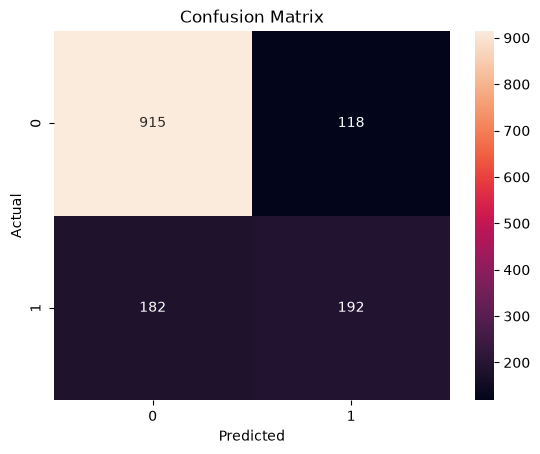

In [112]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [113]:
# Feature names निकाल
ohe = pipeline.named_steps["preprocessor"].named_transformers_["cat"]
cat_features = ohe.get_feature_names_out(cat_cols)

all_features = num_cols + list(cat_features)

coefficients = pipeline.named_steps["model"].coef_[0]

import pandas as pd

importance = pd.DataFrame({
    "Feature": all_features,
    "Importance": coefficients
})

importance["Abs"] = importance["Importance"].abs()
importance = importance.sort_values(by="Abs", ascending=False)

print(importance.head(10))

                        Feature  Importance       Abs
0                        tenure   -1.448308  1.448308
25            Contract_Two year   -1.288951  1.288951
10  InternetService_Fiber optic    1.020333  1.020333
24            Contract_One year   -0.752307  0.752307
2                  TotalCharges    0.693877  0.693877
7              PhoneService_Yes   -0.512750  0.512750
13           OnlineSecurity_Yes   -0.399771  0.399771
19              TechSupport_Yes   -0.374381  0.374381
23          StreamingMovies_Yes    0.341719  0.341719
21              StreamingTV_Yes    0.324654  0.324654


In [114]:
df.to_csv("churn_dashboard_ready.csv", index=False)